# Creative Writing — Analysis Notebook

Evaluates alignment between open-source judges and the Claude Sonnet 4.6 proprietary baseline on the `Disya/eq-bench-creative-writing-v3` dataset (767 stories, 22 metrics, 0–20 scale).

**Sections**
1. Load data
2. Alignment metrics — summary table (MAE, RMSE, Spearman ρ, Kendall τ)
3. Per-category MAE heatmap
4. Cost analysis — throughput & cost/1M tokens
5. MOJO cost analysis — blended cost at key routing thresholds

## Setup

In [1]:
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

POSITIVE_CATEGORIES = [
    "Adherence to Instructions", "Believable Character Actions", "Nuanced Characters",
    "Consistent Voice / Tone of Writing", "Imagery and Descriptive Quality", "Elegant Prose",
    "Emotionally Engaging", "Emotionally Complex", "Coherent",
    "Well-earned Lightness or Darkness", "Sentences Flow Naturally",
    "Overall Reader Engagement", "Overall Impression",
]
NEGATIVE_CATEGORIES = [
    "Meandering", "Weak Dialogue", "Tell-Don't-Show", "Unsurprising or Uncreative",
    "Amateurish", "Purple Prose", "Overwrought",
    "Incongruent Ending Positivity", "Unearned Transformations",
]
ALL_CATEGORIES = POSITIVE_CATEGORIES + NEGATIVE_CATEGORIES
POS_COLS = [f"{c}_score" for c in POSITIVE_CATEGORIES]
NEG_COLS = [f"{c}_score" for c in NEGATIVE_CATEGORIES]
ALL_COLS = POS_COLS + NEG_COLS

def pretty_model(stem: str) -> str:
    s = stem.replace("_result", "")
    s = s.replace("-InstructMode-General", "")  # before generic -Instruct strip
    s = s.replace("-Instruct-2507", "").replace("-Instruct", "")
    s = s.replace("-BF16", "").replace("-it", "")
    s = s.replace("nvidia-nemotron-3-nano-4B", "Nemotron-3-Nano-4B")
    return s

## 1. Load data

In [2]:
ref = pd.read_csv(RESULTS_DIR / BASELINE_FILE)
KEYS = ["index", "model"]

evaluator_dfs = {}
for p in sorted(RESULTS_DIR.glob("*_result.csv")):
    if "claude" in p.name:
        continue
    name = pretty_model(p.stem)
    ev = pd.read_csv(p)
    m = pd.merge(ev, ref, on=KEYS, suffixes=("_ev", "_ref"), how="inner")
    evaluator_dfs[name] = m

print(f"Baseline: {BASELINE_FILE}  ({len(ref)} rows)")
for name, df in evaluator_dfs.items():
    print(f"  {name}: {len(df)} rows")

Baseline: claude_sonnet_4.6_result.csv  (767 rows)
  Qwen3-4B: 767 rows
  Qwen3.5-4B: 767 rows
  gemma-4-E2B: 767 rows
  gemma-4-E4B: 767 rows
  llama-3.2-3B: 767 rows
  Nemotron-3-Nano-4B: 767 rows


## 2. Alignment metrics

Per-model MAE, RMSE (absolute error vs baseline) and Spearman ρ, Kendall τ (rank correlation).

In [3]:
summary_rows = []

for name, m in evaluator_dfs.items():
    pos_diffs, neg_diffs, all_diffs = [], [], []
    all_ev, all_ref_vals = [], []

    for col in ALL_COLS:
        ev_s  = m[f"{col}_ev"].to_numpy(dtype=float)
        ref_s = m[f"{col}_ref"].to_numpy(dtype=float)
        mask  = ~(np.isnan(ev_s) | np.isnan(ref_s))
        diff  = ev_s[mask] - ref_s[mask]
        all_diffs.append(diff)
        all_ev.extend(ev_s[mask])
        all_ref_vals.extend(ref_s[mask])
        if col in POS_COLS:
            pos_diffs.append(diff)
        else:
            neg_diffs.append(diff)

    pos = np.concatenate(pos_diffs)
    neg = np.concatenate(neg_diffs)
    all_d = np.concatenate(all_diffs)
    rho, _ = stats.spearmanr(all_ev, all_ref_vals)
    tau, _ = stats.kendalltau(all_ev, all_ref_vals)

    summary_rows.append({
        "Model":         name,
        "Pos MAE":       round(float(np.mean(np.abs(pos))),  3),
        "Neg MAE":       round(float(np.mean(np.abs(neg))),  3),
        "Overall MAE":   round(float(np.mean(np.abs(all_d))), 3),
        "RMSE":          round(float(np.sqrt(np.mean(all_d**2))), 3),
        "Spearman ρ":    round(float(rho), 3),
        "Kendall τ":     round(float(tau), 3),
    })

summary_df = pd.DataFrame(summary_rows).sort_values("Overall MAE").reset_index(drop=True)
display(summary_df)

print("\nLaTeX table rows:")
for _, r in summary_df.iterrows():
    print(f"{r['Model']:<30} & {r['Pos MAE']:.3f} & {r['Neg MAE']:.3f} & {r['RMSE']:.3f} & {r['Spearman ρ']:.3f} & {r['Kendall τ']:.3f} \\\\")

,Model,Pos MAE,Neg MAE,Overall MAE,RMSE,Spearman ρ,Kendall τ
0,Qwen3.5-4B,1.744,1.970,1.836,2.361,0.861,0.683
1,gemma-4-E2B,2.044,3.139,2.492,3.164,0.804,0.610
2,gemma-4-E4B,2.993,2.880,2.947,3.424,0.823,0.650
3,Nemotron-3-Nano-4B,2.056,4.397,3.014,4.066,0.696,0.498
4,Qwen3-4B,3.527,2.400,3.066,3.573,0.818,0.619
5,llama-3.2-3B,4.002,3.817,3.926,5.218,0.655,0.501



LaTeX table rows:
Qwen3.5-4B                     & 1.744 & 1.970 & 2.361 & 0.861 & 0.683 \\
gemma-4-E2B                    & 2.044 & 3.139 & 3.164 & 0.804 & 0.610 \\
gemma-4-E4B                    & 2.993 & 2.880 & 3.424 & 0.823 & 0.650 \\
Nemotron-3-Nano-4B             & 2.056 & 4.397 & 4.066 & 0.696 & 0.498 \\
Qwen3-4B                       & 3.527 & 2.400 & 3.573 & 0.818 & 0.619 \\
llama-3.2-3B                   & 4.002 & 3.817 & 5.218 & 0.655 & 0.501 \\


## 3. Per-category MAE heatmap

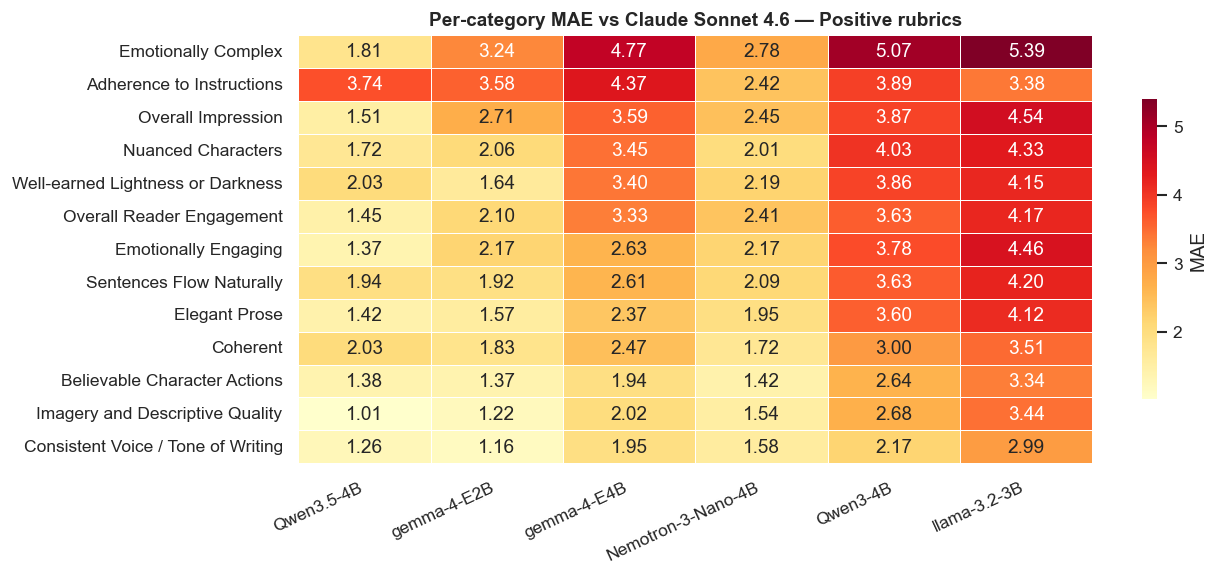

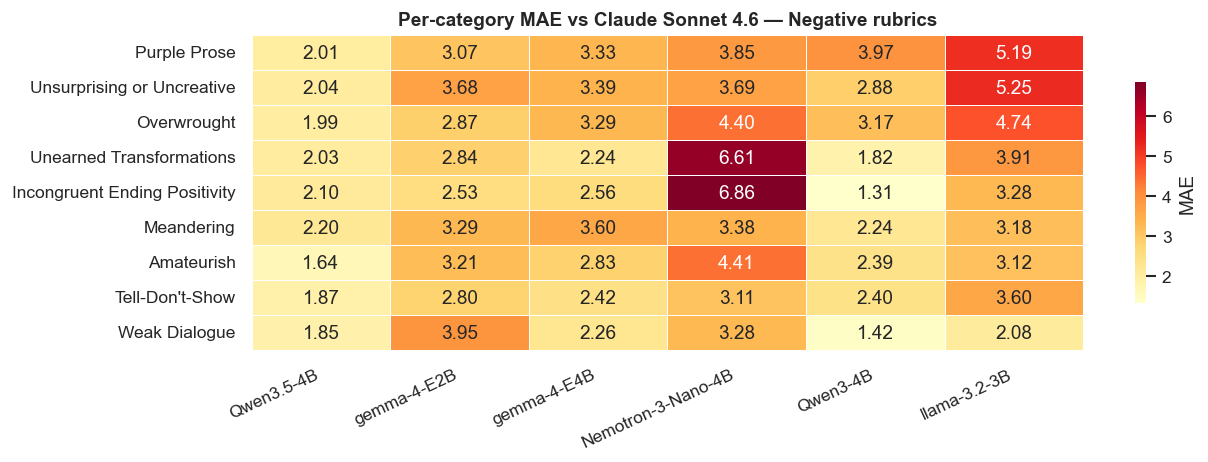

In [4]:
per_cat_rows = []
model_order = summary_df["Model"].tolist()

for name, m in evaluator_dfs.items():
    for col in ALL_COLS:
        ev_s  = m[f"{col}_ev"].to_numpy(dtype=float)
        ref_s = m[f"{col}_ref"].to_numpy(dtype=float)
        mask  = ~(np.isnan(ev_s) | np.isnan(ref_s))
        diff  = ev_s[mask] - ref_s[mask]
        per_cat_rows.append({
            "model":  name,
            "rubric": col.replace("_score", ""),
            "type":   "positive" if col in POS_COLS else "negative",
            "mae":    float(np.mean(np.abs(diff))),
        })

per_cat_df = pd.DataFrame(per_cat_rows)

for cat_type, title in [("positive", "Positive rubrics"), ("negative", "Negative rubrics")]:
    sub    = per_cat_df[per_cat_df["type"] == cat_type]
    pivot  = sub.pivot(index="rubric", columns="model", values="mae")[model_order]
    pivot  = pivot.loc[pivot.mean(axis=1).sort_values(ascending=False).index]

    h = max(4, len(pivot) * 0.38)
    fig, ax = plt.subplots(figsize=(11, h))
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlOrRd", ax=ax,
                linewidths=0.4, cbar_kws={"label": "MAE", "shrink": 0.7})
    ax.set_title(f"Per-category MAE vs Claude Sonnet 4.6 — {title}", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

## 4. Cost analysis

Computes throughput (tok/s) and effective cost per 1M tokens from inference logs.

$$\text{Throughput} = \frac{\sum \text{total\_tokens}}{\sum \text{latency\_s}} \qquad \text{Cost}_{1\text{M}} = \frac{10^6}{\text{Throughput} \times 3600} \times \text{Rate}_{\text{GPU}}$$

In [5]:
def parse_log(path: Path) -> dict:
    tot_tok = lat = prompt = completion = n_ok = n_total = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            n_total += 1
            if e.get("status") == "ok":
                tot_tok    += e["total_tokens"]
                lat        += e["latency_ms"] / 1000
                prompt     += e["prompt_tokens"]
                completion += e["completion_tokens"]
                n_ok += 1
    return dict(n_ok=n_ok, n_total=n_total,
                total_tokens=tot_tok, latency_s=lat,
                prompt_tokens=prompt, completion_tokens=completion)

# Claude baseline
claude_raw = parse_log(LOGS_DIR / "llm_calls_claude-sonnet-4-6.jsonl")
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
CLAUDE_BLENDED = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Claude Sonnet 4.6  |  {claude_raw['n_ok']:,} requests  "
      f"|  blended ${CLAUDE_BLENDED:.2f}/1M tokens")

# Open-source models
cost_rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    tput      = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (tput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (tput * 3600)) * GPU_RATE_HIGH
    name = log_file.stem.replace("llm_calls_", "")
    cost_rows.append(dict(
        model=pretty_model(name),
        log_stem=name,
        n_ok=raw["n_ok"],
        throughput=tput,
        cost_low=cost_low,
        cost_high=cost_high,
        cost_mid=(cost_low + cost_high) / 2,
        reduction_low=CLAUDE_BLENDED / cost_low,
        reduction_high=CLAUDE_BLENDED / cost_high,
    ))

cost_df = pd.DataFrame(cost_rows).sort_values("cost_low").reset_index(drop=True)

disp = cost_df[["model","n_ok","throughput","cost_low","cost_high","reduction_low","reduction_high"]].copy()
disp.columns = ["Model","N (ok)","Throughput (tok/s)","Cost/1M low","Cost/1M high","Reduction low","Reduction high"]
disp["Throughput (tok/s)"] = disp["Throughput (tok/s)"].map("{:.0f}".format)
disp["Cost/1M low"]  = disp["Cost/1M low"].map("${:.3f}".format)
disp["Cost/1M high"] = disp["Cost/1M high"].map("${:.3f}".format)
disp["Reduction low"]  = disp["Reduction low"].map("{:.1f}x".format)
disp["Reduction high"] = disp["Reduction high"].map("{:.1f}x".format)
display(disp)

Claude Sonnet 4.6  |  767 requests  |  blended $4.28/1M tokens


,Model,N (ok),Throughput (tok/s),Cost/1M low,Cost/1M high,Reduction low,Reduction high
0,Llama-3.2-3B,811,2086,$0.266,$0.466,16.1x,9.2x
1,NVIDIA-Nemotron-3-Nano-4B,767,1706,$0.326,$0.570,13.1x,7.5x
2,gemma-4-E2B,767,1525,$0.364,$0.638,11.7x,6.7x
3,Qwen3.5-4B,767,1262,$0.440,$0.770,9.7x,5.6x
4,Qwen3-4B,767,1250,$0.444,$0.778,9.6x,5.5x
5,gemma-4-E4B,767,1012,$0.549,$0.960,7.8x,4.5x


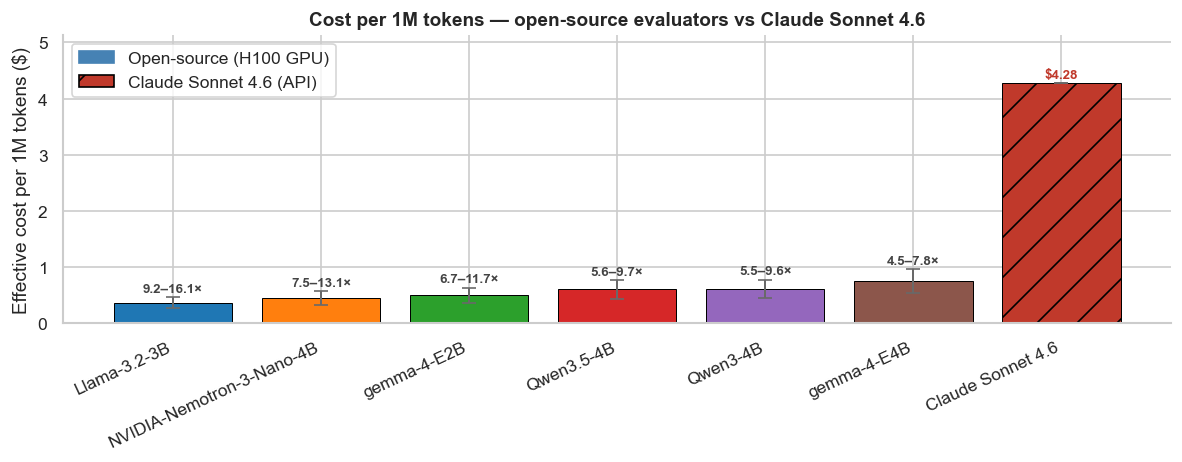

In [6]:
# Bar chart: cost per 1M tokens
fig, ax = plt.subplots(figsize=(10, 4))

labels = cost_df["model"].tolist() + ["Claude Sonnet 4.6"]
mids   = cost_df["cost_mid"].tolist() + [CLAUDE_BLENDED]
errs   = ((cost_df["cost_high"] - cost_df["cost_low"]) / 2).tolist() + [0]
colors = list(sns.color_palette("tab10", n_colors=len(cost_df))) + ["#c0392b"]

x = np.arange(len(labels))
bars = ax.bar(x, mids, yerr=errs, capsize=4, color=colors,
              edgecolor="black", linewidth=0.6,
              error_kw=dict(elinewidth=1.2, ecolor="dimgrey"),
              hatch=[""] * len(cost_df) + ["/"])

for bar, mid, err, rl, rh in zip(
        bars, cost_df["cost_mid"], (cost_df["cost_high"]-cost_df["cost_low"])/2,
        cost_df["reduction_low"], cost_df["reduction_high"]):
    ax.text(bar.get_x() + bar.get_width()/2, mid + err + 0.04,
            f"{rh:.1f}–{rl:.1f}×", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#444")

ax.text(bars[-1].get_x() + bars[-1].get_width()/2, CLAUDE_BLENDED + 0.04,
        f"${CLAUDE_BLENDED:.2f}", ha="center", va="bottom", fontsize=8, fontweight="bold", color="#c0392b")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=25, ha="right")
ax.set_ylabel("Effective cost per 1M tokens ($)")
ax.set_ylim(0, CLAUDE_BLENDED * 1.2)
ax.set_title("Cost per 1M tokens — open-source evaluators vs Claude Sonnet 4.6",
             fontweight="bold")
ax.legend(handles=[
    mpatches.Patch(color="steelblue", label="Open-source (H100 GPU)"),
    mpatches.Patch(facecolor="#c0392b", hatch="/", edgecolor="black", label="Claude Sonnet 4.6 (API)"),
], loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

## 5. MOJO cost analysis

For each MAE threshold τ, MOJO routes each rubric to the cheapest open-source model whose bootstrap UCB-MAE ≤ τ, falling back to Claude otherwise.  
Blended cost = mean over rubrics of (escalated ? `CLAUDE_BLENDED` : `cost_mid[assigned_model]`).

In [7]:
sys.path.insert(0, str(Path("../../figures").resolve()))
from pareto_figures import DATASETS, load_dataset, bootstrap_calibration, operating_point_at_threshold

# Build pretty_name → cost_mid lookup from cost_df
MODEL_COST = dict(zip(cost_df["model"], cost_df["cost_mid"]))

cw_cfg = next(c for c in DATASETS if c.name == "creative_writing")
pairs, errors, evaluator_names = load_dataset(cw_cfg)

# Bootstrap calibration (k=5 subsamples of size √n, 95th-percentile UCB)
cal = bootstrap_calibration(pairs, k=5, alpha=0.05, seed=0)
score_table = (
    cal.pivot_table(index="category", columns="evaluator", values="ucb_mae")
       .reindex(index=cw_cfg.categories, columns=evaluator_names)
)

# Full-data realized MAE per (rubric × model) — used as the lookup once routing is decided
cat_mae = (
    errors.groupby(["evaluator", "category"])["abs_err"].mean()
          .unstack("evaluator")
          .reindex(index=cw_cfg.categories, columns=evaluator_names)
)

n_per_cat = len(errors.groupby(cw_cfg.id_keys + ["category"])["abs_err"].min()) // len(cw_cfg.categories)
print(f"Rubrics: {len(cw_cfg.categories)} | n per rubric: {n_per_cat}")
print(f"Evaluators: {evaluator_names}")
print(f"\nCost lookup ($/1M): {MODEL_COST}")

Rubrics: 22 | n per rubric: 767
Evaluators: ['Qwen3-4B', 'Qwen3.5-4B', 'gemma-4-E2B', 'gemma-4-E4B', 'llama-3.2-3B', 'nvidia-nemotron-3-nano-4B-BF16']

Cost lookup ($/1M): {'Llama-3.2-3B': 0.36614069520924764, 'NVIDIA-Nemotron-3-Nano-4B': 0.4478654314085847, 'gemma-4-E2B': 0.5009650996261064, 'Qwen3.5-4B': 0.6051166078621536, 'Qwen3-4B': 0.6110285509832712, 'gemma-4-E4B': 0.7545551575208305}


In [8]:
# Operating points: No fallback + 4 threshold levels
SCORE_RANGE = 20.0  # CW scale is 0–20
THRESHOLDS  = [("No fallback", float("inf")),
               ("τ=2.6 (13%)",  2.6),
               ("τ=2.2 (11%)",  2.2),
               ("τ=1.8 (9%)",   1.8),
               ("τ=1.3 (6.5%)", 1.3)]

mojo_rows = []
for label, tau in THRESHOLDS:
    # Determine routing decision per rubric
    chosen    = score_table.idxmin(axis=1)     # best surrogate per rubric (lowest UCB MAE)
    chosen_sc = score_table.min(axis=1)        # its calibrated score

    rubric_costs = []
    rubric_maes  = []
    n_escalated  = 0
    for rubric in cw_cfg.categories:
        if pd.isna(chosen[rubric]) or chosen_sc[rubric] > tau:
            # Fallback to Claude
            rubric_costs.append(CLAUDE_BLENDED)
            rubric_maes.append(0.0)  # frontier = perfect alignment
            n_escalated += 1
        else:
            model = chosen[rubric]
            rubric_costs.append(MODEL_COST.get(model, CLAUDE_BLENDED))
            rubric_maes.append(float(cat_mae.loc[rubric, model]))

    blended_cost = float(np.mean(rubric_costs))
    realized_mae = float(np.mean(rubric_maes))
    mojo_rows.append(dict(
        label=label,
        n_escalated=n_escalated,
        blended_cost=blended_cost,
        realized_mae=realized_mae,
        reduction=CLAUDE_BLENDED / blended_cost,
    ))

mojo_df = pd.DataFrame(mojo_rows)
mojo_df["Cost/1M"]    = mojo_df["blended_cost"].map("${:.3f}".format)
mojo_df["Reduction"]  = mojo_df["reduction"].map("{:.1f}×".format)
mojo_df["Realized MAE"] = mojo_df["realized_mae"].map("{:.3f}".format)
display(mojo_df[["label","n_escalated","Cost/1M","Reduction","Realized MAE"]]
          .rename(columns={"label":"Threshold","n_escalated":"Rubrics → Claude"}))

# Paper cost table range (No fallback → tightest threshold with some open-source)
no_fb  = mojo_df[mojo_df["n_escalated"] == 0].iloc[0]
tightest = mojo_df[mojo_df["n_escalated"] < len(cw_cfg.categories)].iloc[-1]
print(f"\nFor cost table (Creative Writing):")
print(f"  MOJO range: ${tightest['blended_cost']:.2f}–${no_fb['blended_cost']:.2f}/1M  "
      f"({no_fb['reduction']:.1f}–{tightest['reduction']:.1f}×)")

,Threshold,Rubrics → Claude,Cost/1M,Reduction,Realized MAE
0,No fallback,0,$0.759,5.6×,1.690
1,τ=2.6 (13%),2,$0.926,4.6×,1.488
2,τ=2.2 (11%),9,$2.099,2.0×,0.874
3,τ=1.8 (9%),12,$2.604,1.6×,0.629
4,τ=1.3 (6.5%),20,$3.939,1.1×,0.099



For cost table (Creative Writing):
  MOJO range: $3.94–$0.76/1M  (5.6–1.1×)
